In [204]:
# imports

import os
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
pd.options.mode.chained_assignment = None  # default='warn'

In [205]:
pd.set_option('display.max_rows', 750)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', None)

# Idée d'application

# Extract & Load

In [206]:
ls -lh ./data

total 13G
-rw-r--r-- 1 mijka mijka 166M 10 août  17:20 clean_openfoodfacts_2.csv
-rw-r--r-- 1 mijka mijka 166M  3 août  17:36 clean_openfoodfacts.csv
-rw-r--r-- 1 mijka mijka 152M  9 nov.  10:01 clean_openfoodfacts_x.csv
-rw-r--r-- 1 mijka mijka 5,6G 22 avril  2022 en.openfoodfacts.org.products.csv
-rw-r--r-- 1 mijka mijka 5,7G 22 avril  2022 fr.openfoodfacts.org.products.csv
-rw-r--r-- 1 mijka mijka 809M 21 avril  2017 fr.openfoodfacts.org.products_old.csv


In [207]:
path = './data/'
csv_path = path + 'fr.openfoodfacts.org.products.csv'
csv_path_old = path + 'fr.openfoodfacts.org.products_old.csv'
#df = pd.read_csv('./data/fr.openfoodfacts.org.products.csv', sep='delimiter', header=None)
#df = pd.read_csv(csv_path, on_bad_lines='skip')
df = pd.read_csv(csv_path, sep='\t', header='infer', on_bad_lines='skip', low_memory=False)
#df_old = pd.read_csv(csv_path_old, sep='\t', header='infer', on_bad_lines='skip', low_memory=False)

# Explore

## Functions

In [208]:
def get_df_columns_na(df):
    counts = df.isna().sum()
    percentages = round(df.isna().mean() * 100, 1)
    null_values = pd.concat([counts, percentages], axis = 1, keys = ["count", "null_percent"])
    null_values['columns'] = null_values.index
    null_values = null_values[['columns', 'count', 'null_percent']]
    return null_values

In [209]:
def plot_df_xy(df, x_val, y_val, height_val = 20, width_val = 13):
    sns.catplot(data=df, x= x_val, y= y_val, kind="bar", height=height_val, aspect=width_val/height_val)
    sns.set(rc={'figure.figsize':(width_val,height_val)})
    plt.xticks(rotation=70)
    plt.tight_layout()

## Cardinality 

In [210]:
df.head()

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,product_name,abbreviated_product_name,generic_name,quantity,packaging,packaging_tags,packaging_fr,packaging_text,brands,brands_tags,categories,categories_tags,categories_fr,origins,origins_tags,origins_fr,manufacturing_places,manufacturing_places_tags,labels,labels_tags,labels_fr,emb_codes,emb_codes_tags,first_packaging_code_geo,cities,cities_tags,purchase_places,stores,countries,countries_tags,countries_fr,ingredients_text,ingredients_tags,allergens,allergens_fr,traces,traces_tags,traces_fr,serving_size,serving_quantity,no_nutriments,additives_n,additives,additives_tags,additives_fr,nutriscore_score,nutriscore_grade,nova_group,pnns_groups_1,pnns_groups_2,food_groups,food_groups_tags,food_groups_fr,states,states_tags,states_fr,brand_owner,ecoscore_score,ecoscore_grade,main_category,main_category_fr,image_url,image_small_url,image_ingredients_url,image_ingredients_small_url,image_nutrition_url,image_nutrition_small_url,energy-kj_100g,energy-kcal_100g,energy_100g,energy-from-fat_100g,fat_100g,saturated-fat_100g,butyric-acid_100g,caproic-acid_100g,caprylic-acid_100g,capric-acid_100g,lauric-acid_100g,myristic-acid_100g,palmitic-acid_100g,stearic-acid_100g,arachidic-acid_100g,behenic-acid_100g,lignoceric-acid_100g,cerotic-acid_100g,montanic-acid_100g,melissic-acid_100g,monounsaturated-fat_100g,polyunsaturated-fat_100g,omega-3-fat_100g,alpha-linolenic-acid_100g,eicosapentaenoic-acid_100g,docosahexaenoic-acid_100g,omega-6-fat_100g,linoleic-acid_100g,arachidonic-acid_100g,gamma-linolenic-acid_100g,dihomo-gamma-linolenic-acid_100g,omega-9-fat_100g,oleic-acid_100g,elaidic-acid_100g,gondoic-acid_100g,mead-acid_100g,erucic-acid_100g,nervonic-acid_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,sucrose_100g,glucose_100g,fructose_100g,lactose_100g,maltose_100g,maltodextrins_100g,starch_100g,polyols_100g,fiber_100g,soluble-fiber_100g,insoluble-fiber_100g,proteins_100g,casein_100g,serum-proteins_100g,nucleotides_100g,salt_100g,sodium_100g,alcohol_100g,vitamin-a_100g,beta-carotene_100g,vitamin-d_100g,vitamin-e_100g,vitamin-k_100g,vitamin-c_100g,vitamin-b1_100g,vitamin-b2_100g,vitamin-pp_100g,vitamin-b6_100g,vitamin-b9_100g,folates_100g,vitamin-b12_100g,biotin_100g,pantothenic-acid_100g,silica_100g,bicarbonate_100g,potassium_100g,chloride_100g,calcium_100g,phosphorus_100g,iron_100g,magnesium_100g,zinc_100g,copper_100g,manganese_100g,fluoride_100g,selenium_100g,chromium_100g,molybdenum_100g,iodine_100g,caffeine_100g,taurine_100g,ph_100g,fruits-vegetables-nuts_100g,fruits-vegetables-nuts-dried_100g,fruits-vegetables-nuts-estimate_100g,fruits-vegetables-nuts-estimate-from-ingredients_100g,collagen-meat-protein-ratio_100g,cocoa_100g,chlorophyl_100g,carbon-footprint_100g,carbon-footprint-from-meat-or-fish_100g,nutrition-score-fr_100g,nutrition-score-uk_100g,glycemic-index_100g,water-hardness_100g,choline_100g,phylloquinone_100g,beta-glucan_100g,inositol_100g,carnitine_100g
0,00000000000000225,http://world-fr.openfoodfacts.org/produit/00000000000000225/jeunes-pousses-endives,nutrinet-sante,1623855208,2021-06-16T14:53:28Z,1623855209,2021-06-16T14:53:29Z,jeunes pousses,NaN,NaN,NaN,NaN,NaN,NaN,NaN,endives,endives,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,en:france,en:france,France,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,unknown,NaN,NaN,NaN,"en:to-be-completed, en:nutrition-facts-to-be-completed, en:ingredients-to-be-completed, en:expiration-date-to-be-completed, en:packaging-code-to-be-completed, en:characteristics-to-be-completed, en:origins-to-be-completed, en:categories-to-be-completed, en:brands-completed, en:packaging-to-be-completed, en:quantity-to-be-completed, en:product-name-completed, en:photos-to-be-uploaded","en:to-be-completed,en:nutrition-facts-to-be-completed,en:ingredients-to-be-completed,en:expiration-date-to-be-completed,en:packaging-code-to-be-completed,en:characteris

In [211]:
df.shape

(2282517, 186)

In [212]:
#df.dtypes

In [213]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2282517 entries, 0 to 2282516
Data columns (total 186 columns):
 #    Column                                                 Dtype  
---   ------                                                 -----  
 0    code                                                   object 
 1    url                                                    object 
 2    creator                                                object 
 3    created_t                                              int64  
 4    created_datetime                                       object 
 5    last_modified_t                                        int64  
 6    last_modified_datetime                                 object 
 7    product_name                                           object 
 8    abbreviated_product_name                               object 
 9    generic_name                                           object 
 10   quantity                                            

In [214]:
df.describe()

,created_t,last_modified_t,cities,allergens_fr,serving_quantity,no_nutriments,additives_n,additives,nutriscore_score,nova_group,ecoscore_score,energy-kj_100g,energy-kcal_100g,energy_100g,energy-from-fat_100g,fat_100g,saturated-fat_100g,butyric-acid_100g,caproic-acid_100g,caprylic-acid_100g,capric-acid_100g,lauric-acid_100g,myristic-acid_100g,palmitic-acid_100g,stearic-acid_100g,arachidic-acid_100g,behenic-acid_100g,lignoceric-acid_100g,cerotic-acid_100g,montanic-acid_100g,melissic-acid_100g,monounsaturated-fat_100g,polyunsaturated-fat_100g,omega-3-fat_100g,alpha-linolenic-acid_100g,eicosapentaenoic-acid_100g,docosahexaenoic-acid_100g,omega-6-fat_100g,linoleic-acid_100g,arachidonic-acid_100g,gamma-linolenic-acid_100g,dihomo-gamma-linolenic-acid_100g,omega-9-fat_100g,oleic-acid_100g,elaidic-acid_100g,gondoic-acid_100g,mead-acid_100g,erucic-acid_100g,nervonic-acid_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,sucrose_100g,glucose_100g,fructose_100g,lactose_100g,maltose_100g,maltodextrins_100g,starch_100g,polyols_100g,fiber_100g,soluble-fiber_100g,insoluble-fiber_100g,proteins_100g,casein_100g,serum-proteins_100g,nucleotides_100g,salt_100g,sodium_100g,alcohol_100g,vitamin-a_100g,beta-carotene_100g,vitamin-d_100g,vitamin-e_100g,vitamin-k_100g,vitamin-c_100g,vitamin-b1_100g,vitamin-b2_100g,vitamin-pp_100g,vitamin-b6_100g,vitamin-b9_100g,folates_100g,vitamin-b12_100g,biotin_100g,pantothenic-acid_100g,silica_100g,bicarbonate_100g,potassium_100g,chloride_100g,calcium_100g,phosphorus_100g,iron_100g,magnesium_100g,zinc_100g,copper_100g,manganese_100g,fluoride_100g,selenium_100g,chromium_100g,molybdenum_100g,iodine_100g,caffeine_100g,taurine_100g,ph_100g,fruits-vegetables-nuts_100g,fruits-vegetables-nuts-dried_100g,fruits-vegetables-nuts-estimate_100g,fruits-vegetables-nuts-estimate-from-ingredients_100g,collagen-meat-protein-ratio_100g,cocoa_100g,chlorophyl_100g,carbon-footprint_100g,carbon-footprint-from-meat-or-fish_100g,nutrition-score-fr_100g,nutrition-score-uk_100g,glycemic-index_100g,water-hardness_100g,choline_100g,phylloquinone_100g,beta-glucan_100g,inositol_100g,carnitine_100g
count,2.282517e+06,2.282517e+06,0.0,0.0,5.308960e+05,0.0,758512.000000,0.0,779842.000000,682466.000000,519430.000000,1.650790e+05,1.762739e+06,1.811944e+06,985.000000,1.802064e+06,1.756627e+06,52.000000,14.000000,16.000000,20.000000,34.000000,30.000000,68.000000,35.000000,208.000000,81.000000,27.000000,30.000000,3.400000e+01,49.000000,48491.000000,48460.000000,2229.000000,1006.000000,139.000000,257.000000,602.000000,515.000000,198.000000,21.000000,26.000000,136.000000,103.000000,5.000000e+00,104.000000,32.000000,11.000000,2.300000e+01,265409.000000,269434.000000,1.801617e+06,1.783380e+06,193.000000,123.000000,92.000000,971.000000,113.000000,295.000000,567.000000,3809.000000,6.588090e+05,3613.000000,3339.000000,1.803504e+06,69.000000,100.000000,61.000000,1.658462e+06,1.658459e+06,2.550800e+04,212980.000000,84.000000,1.052100e+04,3882.000000,1295.000000,220833.000000,24000.000000,23097.000000,24124.000000,16414.000000,10574.000000,8499.000000,1.335800e+04,1.296000e+03,6384.000000,195.000000,483.000000,92758.000000,892.000000,2.719940e+05,14202.000000,265786.000000,15070.000000,1.046100e+04,4389.000000,4175.000000,423.000000,2637.000000,235.000000,386.000000,2509.000000,581.000000,266.000000,263.000000,9888.000000,912.000000,11950.000000,757180.000000,319.000000,6731.000000,5.000000,489.000000,12138.000000,779846.000000,6.000000,5.0000,2.000000,74.000000,1712.000000,41.000000,77.000000,45.000000
mean,1.570776e+09,1.610378e+09,NaN,NaN,2.092906e+16,NaN,2.011496,NaN,9.090063,3.381807,43.566772,4.037799e+37,-2.761410e+12,3.678678e+36,326.853198,5.549852e+11,5.689469e+04,2.374829,4.052359,9.841825,5.104565,123.329271,37.434977,54.254182,18.761002,14.480708,3.200423,13.956595,22.638184,3.812452e+01,17.389914,10.086743,5.946296,18.879255,7.280367,3.015702,4.358535,27.227854,3.748984,6.816863,4.184841,21.785470,178.404401,16.818433,1.500042e+00,

### time format

In [215]:
print(df.iloc[:,df.columns.str.endswith('_t')].head())
print('\n', df.iloc[:,df.columns.str.endswith('_datetime')].head())

    created_t  last_modified_t
0  1623855208       1623855209
1  1630483911       1630484064
2  1529059080       1561463718
3  1539464774       1539464817
4  1574175736       1624390765

        created_datetime last_modified_datetime
0  2021-06-16T14:53:28Z   2021-06-16T14:53:29Z
1  2021-09-01T08:11:51Z   2021-09-01T08:14:24Z
2  2018-06-15T10:38:00Z   2019-06-25T11:55:18Z
3  2018-10-13T21:06:14Z   2018-10-13T21:06:57Z
4  2019-11-19T15:02:16Z   2021-06-22T19:39:25Z


=> "_t" fields are in UNIX timestamp format

=> "_datetime" fiels are in UTC ISO 8601 format

=> they are duplicates, might need to only keep the ISO 8601

In [216]:
def clean_datetime(df):
    columns = df.columns
    columns_result = []
    for column in columns:
        if column[-2:] == '_t':
            df = df.drop(column, axis=1)     
    return df

In [217]:
df = clean_datetime(df)

In [218]:
df.shape

(2282517, 184)

In [219]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2282517 entries, 0 to 2282516
Data columns (total 184 columns):
 #    Column                                                 Dtype  
---   ------                                                 -----  
 0    code                                                   object 
 1    url                                                    object 
 2    creator                                                object 
 3    created_datetime                                       object 
 4    last_modified_datetime                                 object 
 5    product_name                                           object 
 6    abbreviated_product_name                               object 
 7    generic_name                                           object 
 8    quantity                                               object 
 9    packaging                                              object 
 10   packaging_tags                                      

In [220]:
print(df.iloc[:,df.columns.str.endswith('_t')].head())
print('\n', df.iloc[:,df.columns.str.endswith('_datetime')].head())

Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4]

        created_datetime last_modified_datetime
0  2021-06-16T14:53:28Z   2021-06-16T14:53:29Z
1  2021-09-01T08:11:51Z   2021-09-01T08:14:24Z
2  2018-06-15T10:38:00Z   2019-06-25T11:55:18Z
3  2018-10-13T21:06:14Z   2018-10-13T21:06:57Z
4  2019-11-19T15:02:16Z   2021-06-22T19:39:25Z


### Countries

In [221]:
# count distinct values
df.countries.nunique()

12094

In [222]:
# show values
df.countries.unique().tolist()

['en:france',
 'Spain',
 'France',
 'Espagne',
 'en:es',
 'en:United States',
 'en:fr',
 'United States',
 'en:France',
 'Irlande',
 'en:FR',
 nan,
 'en:be',
 'United Kingdom',
 'États-Unis, en:france',
 'France, United States',
 'France,États-Unis',
 'España',
 'en:Ivory Coast',
 'Canada',
 'en:United Kingdom',
 'Suisse',
 'en:it',
 'Germany',
 'France,Belgique',
 'Belgium',
 'France, États-Unis',
 'Pérou',
 'en:germany',
 'en:united-kingdom',
 'Schweiz',
 'en:us',
 'Oman',
 'Deutschland',
 'Slovenia',
 'en:DE',
 'en:de',
 'en:gb',
 'Frankreich, Deutschland',
 'France,Germany,Netherlands',
 'en:KW',
 'ફ્રાન્સ',
 'en:spain',
 'Belgien, Germany',
 'en:ae',
 'us',
 'France,Switzerland',
 'Frankreich, en:de',
 'France, en:de',
 'en:India',
 'Italy',
 'Romania',
 'en:US',
 'Australia',
 'en:Norway',
 'Spanien, Germany',
 'en:ch',
 'Malaysia',
 'en:ca',
 'en:lu',
 'en:Spain',
 'en:United Arab Emirates',
 'en:Italy',
 'Portugal',
 'en:Mexico',
 'en:Dominican Republic',
 'Frankreich, Germany'

In [223]:
# should we keep only French related "countries ?"

## Missing Data 

In [224]:
data_na = get_df_columns_na(df)

In [225]:
pd.set_option('display.max_rows', None)
data_na

,columns,count,null_percent
code,code,0,0.0
url,url,0,0.0
creator,creator,4,0.0
created_datetime,created_datetime,0,0.0
last_modified_datetime,last_modified_datetime,0,0.0
product_name,product_name,86006,3.8
abbreviated_product_name,abbreviated_product_name,2274653,99.7
generic_name,generic_name,2154980,94.4
quantity,quantity,1699201,74.4
packaging,packaging,1946191,85.3


In [226]:
chol_row = data_na.loc[data_na['columns'][['code','phylloquinone_100g', 'inositol_100g', 'fruits-vegetables-nuts-estimate-from-ingredients_100g']]]
chol_row

,columns,count,null_percent
code,code,0,0.0
phylloquinone_100g,phylloquinone_100g,2280805,99.9
inositol_100g,inositol_100g,2282440,100.0
fruits-vegetables-nuts-estimate-from-ingredients_100g,fruits-vegetables-nuts-estimate-from-ingredients_100g,1525337,66.8


In [227]:
data_na_sort = data_na.sort_values(by='null_percent',ascending=False)
data_na_sort

,columns,count,null_percent
carnitine_100g,carnitine_100g,2282472,100.0
fructose_100g,fructose_100g,2282425,100.0
oleic-acid_100g,oleic-acid_100g,2282414,100.0
elaidic-acid_100g,elaidic-acid_100g,2282512,100.0
gondoic-acid_100g,gondoic-acid_100g,2282413,100.0
mead-acid_100g,mead-acid_100g,2282485,100.0
erucic-acid_100g,erucic-acid_100g,2282506,100.0
nervonic-acid_100g,nervonic-acid_100g,2282494,100.0
sucrose_100g,sucrose_100g,2282324,100.0
glucose_100g,glucose_100g,2282394,100.0


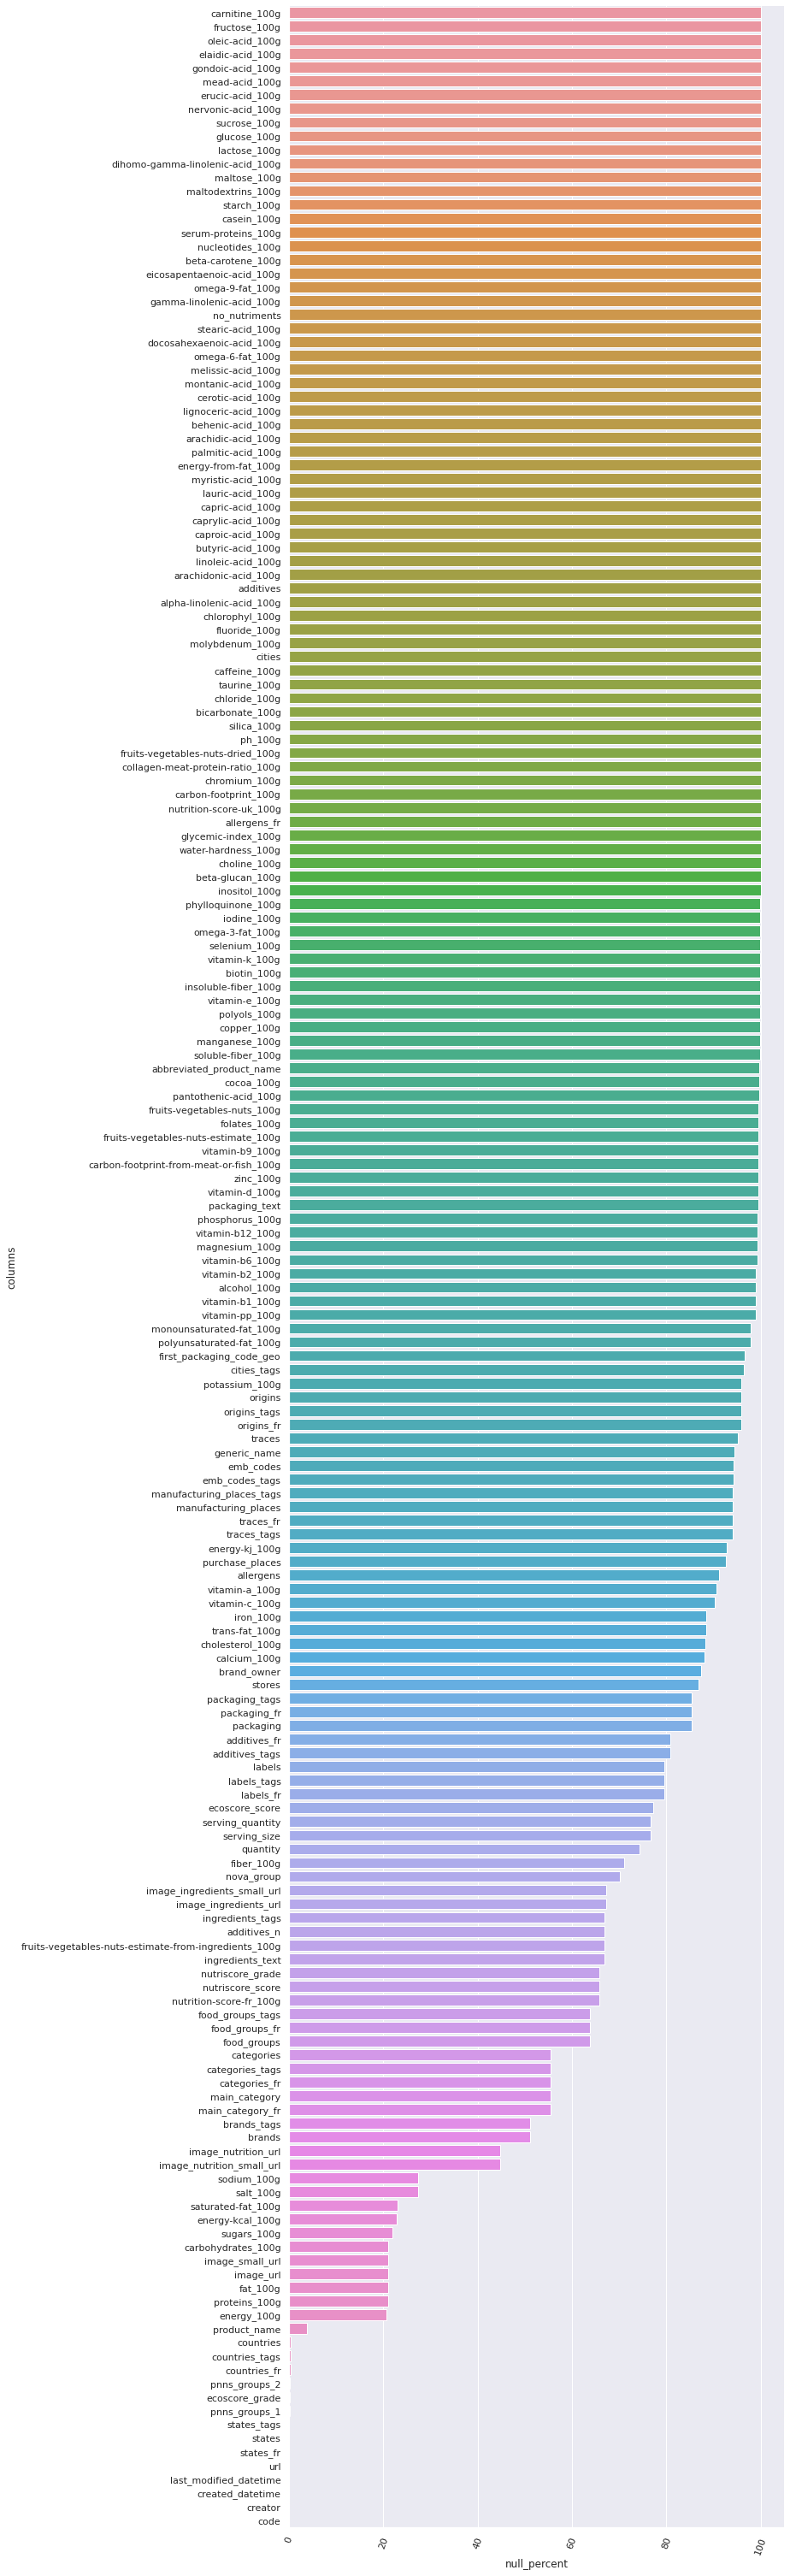

In [228]:
plot_df_xy(data_na_sort.reset_index(), 'null_percent', 'columns', 42)

In [229]:
#nan_values = df.isnull().sum()
#nan_percent = nan_values /df.shape[0]*100


In [230]:
#nan_values

In [231]:
#plot_df_xy(data=nan_values, nan_percent, nan_percent.index)

In [232]:
#plt.figure(figsize=(30, 8))
#sns.distplot(nan_values, kde=False, bins=np.int(df.shape[0]/10000))


In [233]:
# find columns with 6+5% missing values
top_df_high_miss = data_na.loc[data_na["null_percent"] >= 65].index

# drop columns with +65% missing values
top_df = df.drop(top_df_high_miss, axis = 1)
top_df.columns

Index(['code', 'url', 'creator', 'created_datetime', 'last_modified_datetime',
       'product_name', 'brands', 'brands_tags', 'categories',
       'categories_tags', 'categories_fr', 'countries', 'countries_tags',
       'countries_fr', 'pnns_groups_1', 'pnns_groups_2', 'food_groups',
       'food_groups_tags', 'food_groups_fr', 'states', 'states_tags',
       'states_fr', 'ecoscore_grade', 'main_category', 'main_category_fr',
       'image_url', 'image_small_url', 'image_nutrition_url',
       'image_nutrition_small_url', 'energy-kcal_100g', 'energy_100g',
       'fat_100g', 'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g',
       'proteins_100g', 'salt_100g', 'sodium_100g'],
      dtype='object')

In [234]:
#top_df.sort_values(by='null_percent',ascending=False)
#top_df

In [235]:
top_df_sort = get_df_columns_na(top_df).sort_values(by='null_percent',ascending=False)
top_df_sort

,columns,count,null_percent
food_groups,food_groups,1455381,63.8
food_groups_fr,food_groups_fr,1455381,63.8
food_groups_tags,food_groups_tags,1455381,63.8
main_category_fr,main_category_fr,1266614,55.5
categories,categories,1266596,55.5
categories_tags,categories_tags,1266614,55.5
categories_fr,categories_fr,1266614,55.5
main_category,main_category,1266614,55.5
brands,brands,1166217,51.1
brands_tags,brands_tags,1166294,51.1


In [236]:
top_nan_values = top_df.isnull().sum()
top_nan_percent = top_nan_values /top_df.shape[0]*100

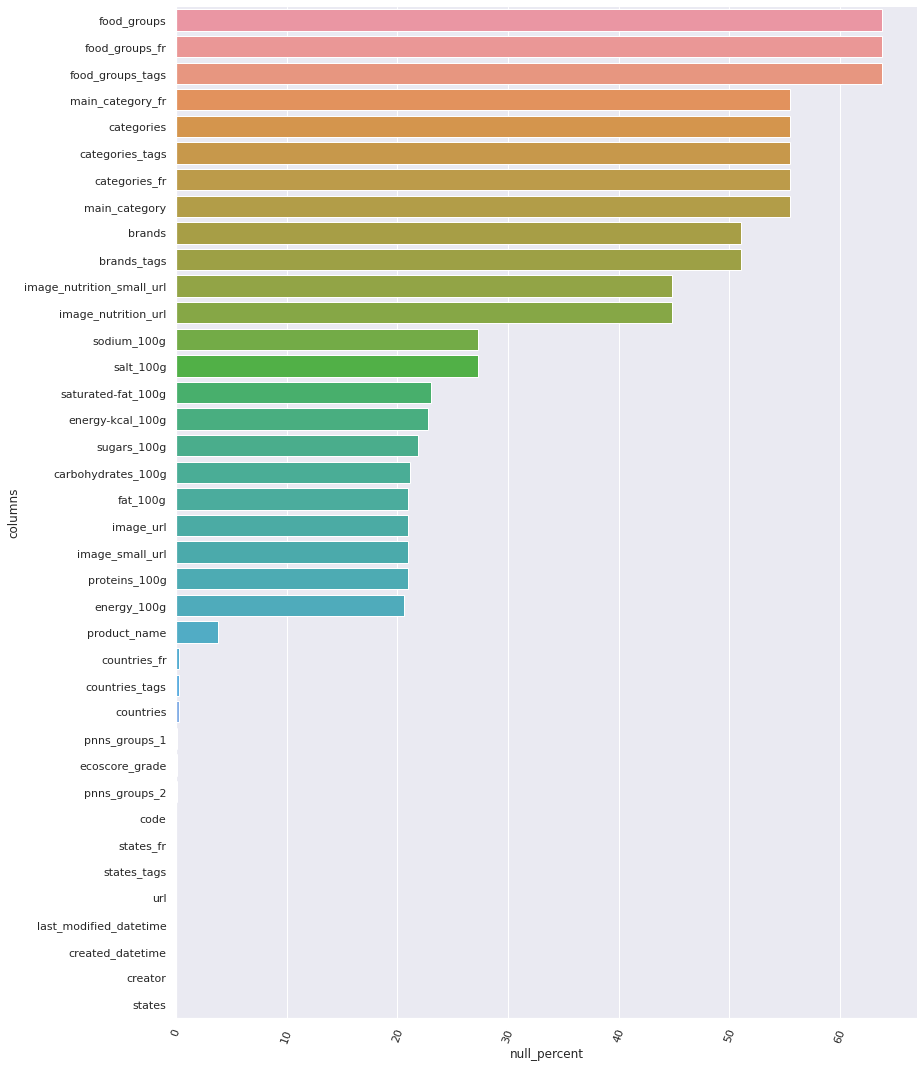

In [237]:
# top_df_sort = get_df_columns_na(top_df).sort_values(by='null_percent',ascending=False)
plot_df_xy(top_df_sort.reset_index(), 'null_percent', 'columns', 15)

### use categories

#### identify categories

In [238]:
#print(df.apply(lambda col: col.unique()))

In [239]:
top_df['pnns_groups_1'].nunique()

12

In [240]:
top_df['pnns_groups_2'].nunique()

42

In [241]:
top_df['main_category_fr'].nunique()

35541

In [242]:
top_df['pnns_groups_1'].head(50)

0                   unknown
1                   unknown
2                   unknown
3                   unknown
4                   unknown
5                   unknown
6                   unknown
7                   unknown
8            Fat and sauces
9                   unknown
10                  unknown
11                  unknown
12                  unknown
13                  unknown
14                  unknown
15                  unknown
16                  unknown
17                  unknown
18          Composite foods
19                  unknown
20                  unknown
21                  unknown
22                  unknown
23                  unknown
24                  unknown
25                  unknown
26                  unknown
27            Sugary snacks
28                  unknown
29                  unknown
30                  unknown
31                  unknown
32                  unknown
33                  unknown
34                  unknown
35                  

In [243]:
top_df['pnns_groups_1'].unique()

array(['unknown', 'Fat and sauces', 'Composite foods', 'Sugary snacks',
       'Fruits and vegetables', 'Fish Meat Eggs', 'Beverages',
       'Milk and dairy products', 'Cereals and potatoes', 'Salty snacks',
       'Alcoholic beverages', nan, 'sugary-snacks'], dtype=object)

In [244]:
top_df['pnns_groups_2'].unique()

array(['unknown', 'Dressings and sauces', 'One-dish meals',
       'Biscuits and cakes', 'Fruits', 'Meat', 'Sweets',
       'Sweetened beverages', 'Cheese', 'Bread', 'Fish and seafood',
       'Salty and fatty products', 'Fruit juices', 'Dried fruits',
       'Vegetables', 'Fats', 'Dairy desserts', 'Milk and yogurt',
       'Pastries', 'Pizza pies and quiches', 'Legumes',
       'Unsweetened beverages', 'Nuts', 'Cereals', 'Alcoholic beverages',
       'Breakfast cereals', 'Appetizers', 'Processed meat',
       'Chocolate products', 'Eggs', 'Plant-based milk substitutes',
       'Sandwiches', 'Ice cream', 'Soups',
       'Teas and herbal teas and coffees', 'Potatoes',
       'Artificially sweetened beverages', 'Waters and flavored waters',
       nan, 'Offals', 'Fruit nectars', 'pastries',
       'Pizza pies and quiche'], dtype=object)

In [245]:
top_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2282517 entries, 0 to 2282516
Data columns (total 38 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   code                       object 
 1   url                        object 
 2   creator                    object 
 3   created_datetime           object 
 4   last_modified_datetime     object 
 5   product_name               object 
 6   brands                     object 
 7   brands_tags                object 
 8   categories                 object 
 9   categories_tags            object 
 10  categories_fr              object 
 11  countries                  object 
 12  countries_tags             object 
 13  countries_fr               object 
 14  pnns_groups_1              object 
 15  pnns_groups_2              object 
 16  food_groups                object 
 17  food_groups_tags           object 
 18  food_groups_fr             object 
 19  states                     object 
 20  st

In [246]:
top_df.shape

(2282517, 38)

In [247]:
top_df['pnns_groups_1'].value_counts()

unknown                    1461312
Sugary snacks               169932
Fish Meat Eggs              115729
Milk and dairy products     102703
Cereals and potatoes         95597
Fat and sauces               79141
Beverages                    75157
Fruits and vegetables        62980
Composite foods              60640
Salty snacks                 37917
Alcoholic beverages          20222
sugary-snacks                    2
Name: pnns_groups_1, dtype: int64

In [248]:
top_df['pnns_groups_1'].value_counts()

unknown                    1461312
Sugary snacks               169932
Fish Meat Eggs              115729
Milk and dairy products     102703
Cereals and potatoes         95597
Fat and sauces               79141
Beverages                    75157
Fruits and vegetables        62980
Composite foods              60640
Salty snacks                 37917
Alcoholic beverages          20222
sugary-snacks                    2
Name: pnns_groups_1, dtype: int64

In [249]:
top_df['pnns_groups_2'].value_counts()

unknown                             1461312
Sweets                                76927
Biscuits and cakes                    69106
Dressings and sauces                  55144
Cheese                                51147
One-dish meals                        46481
Cereals                               45639
Processed meat                        43191
Meat                                  35899
Milk and yogurt                       35794
Vegetables                            34093
Fish and seafood                      31028
Bread                                 25133
Sweetened beverages                   24652
Fats                                  23997
Alcoholic beverages                   20224
Fruits                                19007
Chocolate products                    16556
Salty and fatty products              15645
Appetizers                            13323
Unsweetened beverages                 12344
Breakfast cereals                     11010
Fruit juices                    

<AxesSubplot:xlabel='pnns_groups_1', ylabel='Count'>

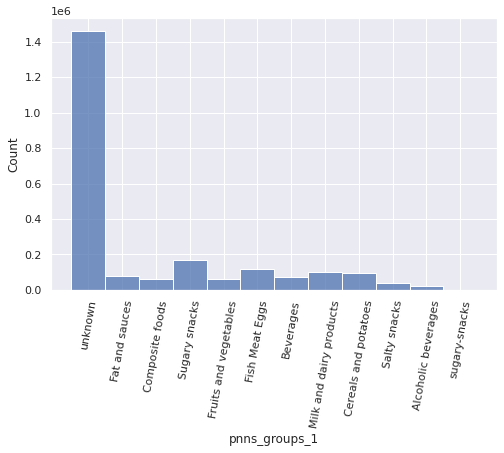

In [250]:
plt.figure(figsize=(8, 5))
plt.xticks(rotation=80)
sns.histplot(data=top_df, x="pnns_groups_1")

In [251]:
## select main features

In [252]:
sm_df = top_df.loc[:,['product_name', 'pnns_groups_1', 'pnns_groups_2', 'code', 'energy-kcal_100g', 'energy_100g',
       'fat_100g', 'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g',
       'proteins_100g', 'salt_100g', 'sodium_100g']]

In [253]:
df.shape

(2282517, 184)

In [254]:
sm_df.shape

(2282517, 13)

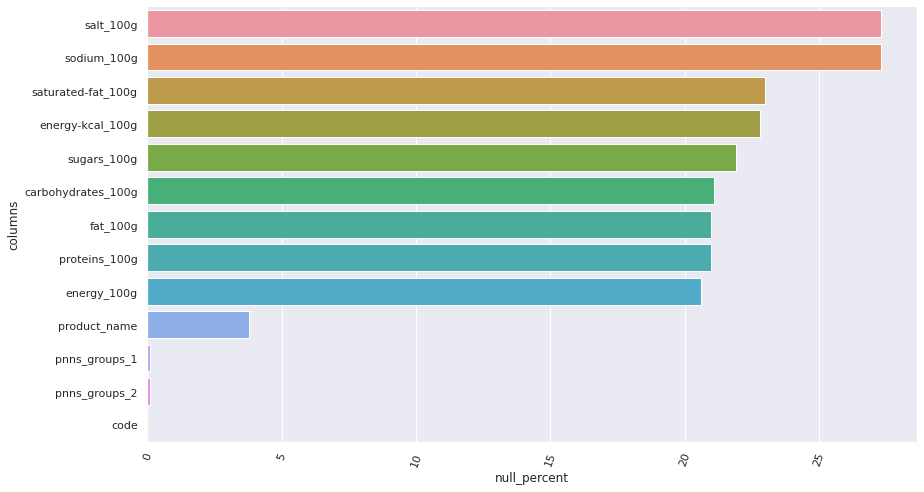

In [255]:
top_sm_df = get_df_columns_na(sm_df).sort_values(by='null_percent',ascending=False)
plot_df_xy(top_sm_df.reset_index(), 'null_percent', 'columns', 7)

In [256]:
top_sm_df

,columns,count,null_percent
salt_100g,salt_100g,624055,27.3
sodium_100g,sodium_100g,624058,27.3
saturated-fat_100g,saturated-fat_100g,525890,23.0
energy-kcal_100g,energy-kcal_100g,519778,22.8
sugars_100g,sugars_100g,499137,21.9
carbohydrates_100g,carbohydrates_100g,480900,21.1
fat_100g,fat_100g,480453,21.0
proteins_100g,proteins_100g,479013,21.0
energy_100g,energy_100g,470573,20.6
product_name,product_name,86006,3.8


In [257]:
sm_df.head(50)

,product_name,pnns_groups_1,pnns_groups_2,code,energy-kcal_100g,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
0,jeunes pousses,unknown,unknown,00000000000000225,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,L.casei,unknown,unknown,00000000000003429145,NaN,NaN,1.4,0.90,9.8,9.80,2.7,0.100,0.0400
2,Vitória crackers,unknown,unknown,0000000000017,375.0,1569.0,7.0,3.08,70.1,15.00,7.8,1.400,0.5600
3,Cacao,unknown,unknown,0000000000031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Filetes de pollo empanado,unknown,unknown,000000000003327986,163.9,685.8,1.9,1.00,NaN,NaN,15.3,1.100,0.4400
5,Burger Meat Pollo,unknown,unknown,000000000004128579,194.0,812.0,11.0,3.90,5.7,0.05,18.0,NaN,NaN
6,Hamburguesas de ternera 100%,unknown,unknown,000000000004622327,874.9,3661.0,15.1,6.10,2.6,1.00,15.7,2.100,0.8400
7,hyde icon,unknown,unknown,00000000001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,moutarde au moût de raisin,Fat and sauces,Dressings and sauces,0000000000100,NaN,936.0,8.2,2.20,29.0,22.00,5.1,4.600,1.8400
9,Sauce Sweety chili 0%,unknown,unknown,0000000000123,21.0,88.0,0.0,0.00,4.8,0.40,0.2,2.040,0.8160


In [258]:
sm_df.loc[:,['pnns_groups_1', 'pnns_groups_2']].head()

,pnns_groups_1,pnns_groups_2
0,unknown,unknown
1,unknown,unknown
2,unknown,unknown
3,unknown,unknown
4,unknown,unknown


# Id & replacing wrong values

##  Impossible values (negative / over maximum)

In [259]:
def show_nulls(df):
    top_sm_df_sort = get_df_columns_na(df).sort_values(by='null_percent',ascending=False)
    print(top_sm_df_sort)
    return plot_df_xy(top_sm_df_sort.reset_index(), 'null_percent', 'columns', 8)

                               columns   count  null_percent
salt_100g                    salt_100g  624055          27.3
sodium_100g                sodium_100g  624058          27.3
saturated-fat_100g  saturated-fat_100g  525890          23.0
energy-kcal_100g      energy-kcal_100g  519778          22.8
sugars_100g                sugars_100g  499137          21.9
carbohydrates_100g  carbohydrates_100g  480900          21.1
fat_100g                      fat_100g  480453          21.0
proteins_100g            proteins_100g  479013          21.0
energy_100g                energy_100g  470573          20.6
product_name              product_name   86006           3.8
pnns_groups_1            pnns_groups_1    1185           0.1
pnns_groups_2            pnns_groups_2    1183           0.1
code                              code       0           0.0


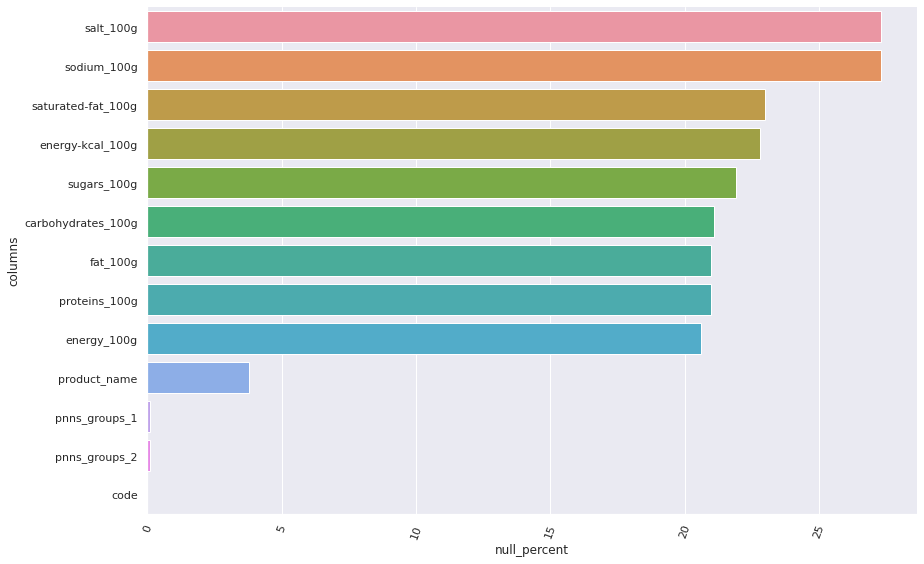

In [260]:
#to_remove check
show_nulls(sm_df)

In [261]:
sm_df.describe()

,energy-kcal_100g,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
count,1.762739e+06,1.811944e+06,1.802064e+06,1.756627e+06,1.801617e+06,1.783380e+06,1.803504e+06,1.658462e+06,1.658459e+06
mean,-2.761410e+12,3.678678e+36,5.549852e+11,5.689469e+04,5.549761e+04,5.612935e+07,5.542326e+04,6.025910e+04,2.410369e+04
std,3.666355e+15,4.951812e+39,7.449290e+14,7.539941e+07,7.445202e+07,7.488214e+10,7.441306e+07,7.759880e+07,3.103955e+07
min,-4.867753e+18,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00,-1.000000e+00,-5.000000e+02,0.000000e+00,0.000000e+00
25%,1.000000e+02,4.180000e+02,8.000000e-01,1.000000e-01,3.530000e+00,6.000000e-01,1.300000e+00,8.500000e-02,3.400000e-02
50%,2.590000e+02,1.079000e+03,7.000000e+00,1.800000e+00,1.540000e+01,3.570000e+00,6.000000e+00,5.900000e-01,2.360000e-01
75%,4.000000e+02,1.674000e+03,2.121000e+01,7.000000e+00,5.300000e+01,1.710000e+01,1.250000e+01,1.400000e+00,5.600000e-01
max,1.000000e+14,6.665559e+42,1.000000e+18,9.993273e+10,9.993273e+10,1.000000e+14,9.993273e+10,9.993273e+10,3.997309e+10


In [262]:
sm_df.columns

Index(['product_name', 'pnns_groups_1', 'pnns_groups_2', 'code',
       'energy-kcal_100g', 'energy_100g', 'fat_100g', 'saturated-fat_100g',
       'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'salt_100g',
       'sodium_100g'],
      dtype='object')

In [263]:
sm_num_cols = ['fat_100g', 'saturated-fat_100g',
       'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'salt_100g',
       'sodium_100g']
energy_cols = ['energy-kcal_100g', 'energy_100g']

In [264]:
# handling columns with negative values
for x in ['energy-kcal_100g', 'carbohydrates_100g', 'sugars_100g', 'proteins_100g']:
    sm_df[x].loc[sm_df[x] < 0] = np.nan

                               columns   count  null_percent
salt_100g                    salt_100g  624055          27.3
sodium_100g                sodium_100g  624058          27.3
saturated-fat_100g  saturated-fat_100g  525890          23.0
energy-kcal_100g      energy-kcal_100g  519779          22.8
sugars_100g                sugars_100g  499141          21.9
carbohydrates_100g  carbohydrates_100g  480901          21.1
fat_100g                      fat_100g  480453          21.0
proteins_100g            proteins_100g  479015          21.0
energy_100g                energy_100g  470573          20.6
product_name              product_name   86006           3.8
pnns_groups_1            pnns_groups_1    1185           0.1
pnns_groups_2            pnns_groups_2    1183           0.1
code                              code       0           0.0


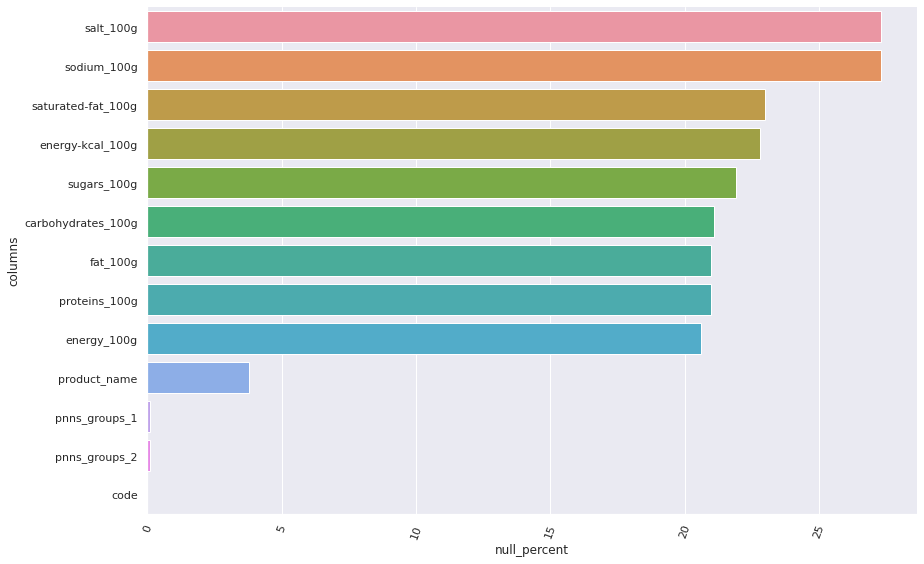

In [265]:
#to_remove check
show_nulls(sm_df)

In [266]:
# handling columns with over max (100) values
for x in sm_num_cols : 
    sm_df[x].loc[sm_df[x] >= 100] = np.nan

                               columns   count  null_percent
salt_100g                    salt_100g  625774          27.4
sodium_100g                sodium_100g  624949          27.4
saturated-fat_100g  saturated-fat_100g  526161          23.1
energy-kcal_100g      energy-kcal_100g  519779          22.8
sugars_100g                sugars_100g  502845          22.0
fat_100g                      fat_100g  490368          21.5
carbohydrates_100g  carbohydrates_100g  489148          21.4
proteins_100g            proteins_100g  479469          21.0
energy_100g                energy_100g  470573          20.6
product_name              product_name   86006           3.8
pnns_groups_1            pnns_groups_1    1185           0.1
pnns_groups_2            pnns_groups_2    1183           0.1
code                              code       0           0.0


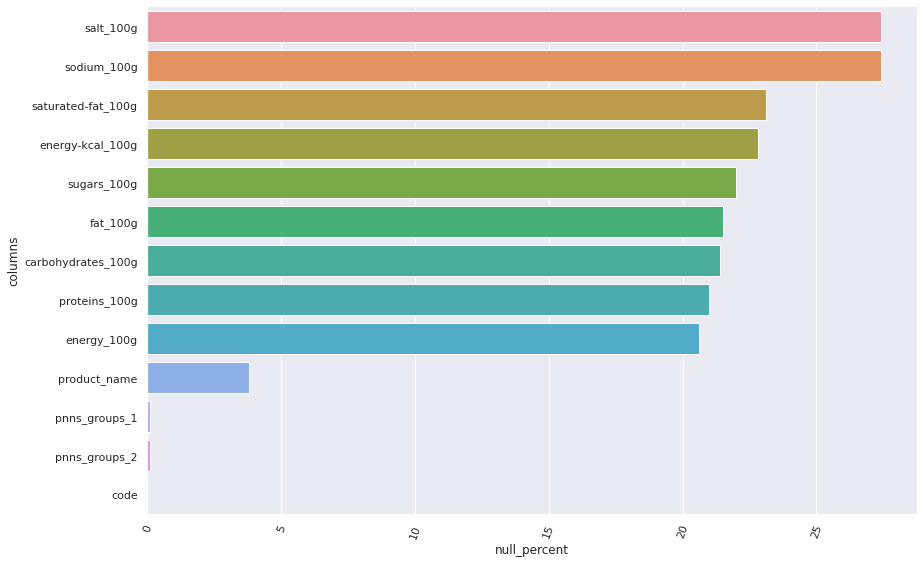

In [267]:
#to_remove check
show_nulls(sm_df)

In [268]:
# max cal = fat
# fat max cal = 9 kCal or Calories per gram of fat
# 100g of fat = 900 kCal / Calories
for x in energy_cols : 
    sm_df[x].loc[sm_df[x] >= 900] = np.nan

                               columns    count  null_percent
energy_100g                energy_100g  1498371          65.6
salt_100g                    salt_100g   625774          27.4
sodium_100g                sodium_100g   624949          27.4
energy-kcal_100g      energy-kcal_100g   533748          23.4
saturated-fat_100g  saturated-fat_100g   526161          23.1
sugars_100g                sugars_100g   502845          22.0
fat_100g                      fat_100g   490368          21.5
carbohydrates_100g  carbohydrates_100g   489148          21.4
proteins_100g            proteins_100g   479469          21.0
product_name              product_name    86006           3.8
pnns_groups_1            pnns_groups_1     1185           0.1
pnns_groups_2            pnns_groups_2     1183           0.1
code                              code        0           0.0


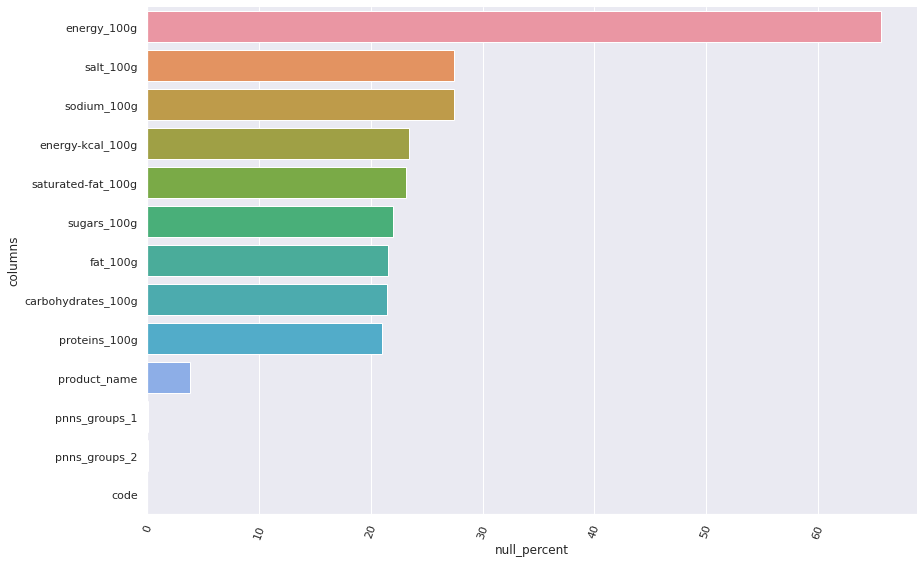

In [269]:
#to_remove check
show_nulls(sm_df)

In [270]:
# energy_100 has 60+ % null values => drop 
sm_df.drop('energy_100g', axis = 1, inplace=True)
energy_cols = ['energy-kcal_100g'] 

In [271]:
sm_df.describe()

,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
count,1.748769e+06,1.792149e+06,1.756356e+06,1.793369e+06,1.779672e+06,1.803048e+06,1.656743e+06,1.657568e+06
mean,2.673871e+02,1.321892e+01,5.042193e+00,2.777051e+01,1.279752e+01,8.730867e+00,1.342707e+00,5.612070e-01
std,1.872935e+02,1.654867e+01,7.763594e+00,2.756309e+01,1.897337e+01,1.005483e+01,4.376132e+00,2.080489e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+02,8.000000e-01,1.000000e-01,3.500000e+00,6.000000e-01,1.300000e+00,8.382000e-02,3.400000e-02
50%,2.564103e+02,6.900000e+00,1.800000e+00,1.510000e+01,3.570000e+00,6.000000e+00,5.892800e-01,2.360000e-01
75%,3.980000e+02,2.100000e+01,7.000000e+00,5.260000e+01,1.700000e+01,1.250000e+01,1.400000e+00,5.600000e-01
max,8.999100e+02,9.999000e+01,9.990000e+01,9.999000e+01,9.999000e+01,9.990000e+01,9.999000e+01,9.880000e+01


[Text(0, 0, 'fat_100g'),
 Text(1, 0, 'saturated-fat_100g'),
 Text(2, 0, 'carbohydrates_100g'),
 Text(3, 0, 'sugars_100g'),
 Text(4, 0, 'proteins_100g'),
 Text(5, 0, 'salt_100g'),
 Text(6, 0, 'sodium_100g')]

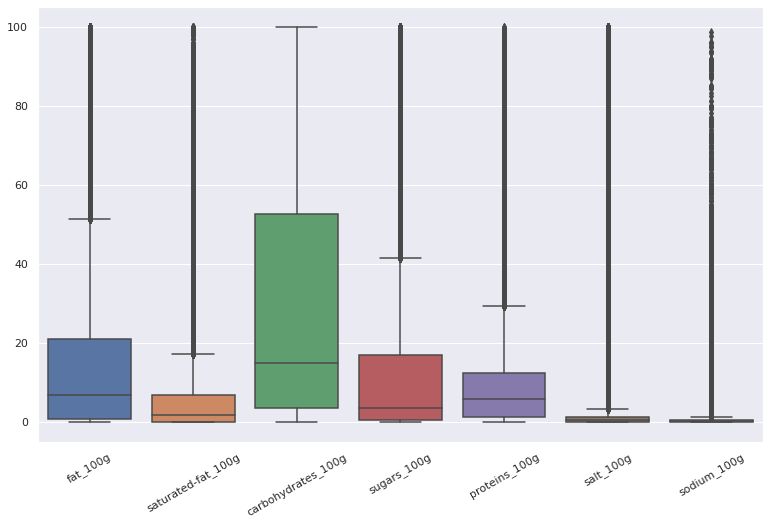

In [272]:
ax = sns.boxplot(data=sm_df[sm_num_cols])
ax.set_xticklabels(ax.get_xticklabels(),rotation=30)

In [273]:
#plt.figure(figsize=(8, 5))
#boxplot = sm_df.boxplot(column=sm_num_cols)
#plt.xticks(rotation=80)

[Text(0, 0, '0')]

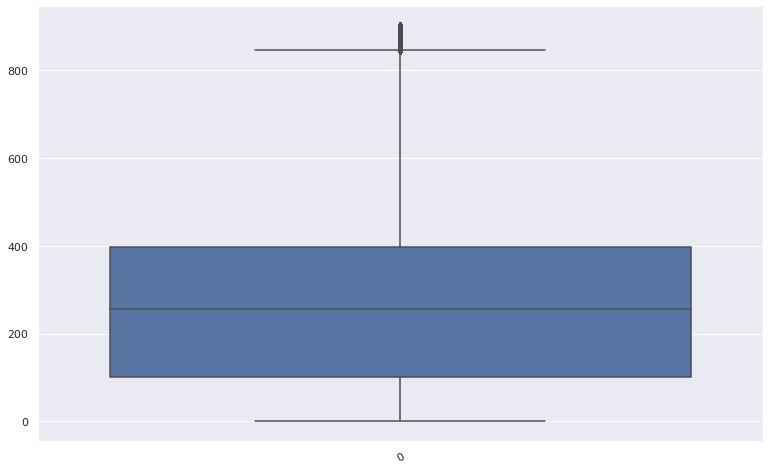

In [274]:
#boxplot = sm_df.boxplot(column=energy_cols)
ax = sns.boxplot(data=sm_df['energy-kcal_100g'])
ax.set_xticklabels(ax.get_xticklabels(),rotation=30)

#### Checking sum of "per 100g" components

In [275]:
sm_df[sm_num_cols].head()

,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.4,0.90,9.8,9.8,2.7,0.1,0.04
2,7.0,3.08,70.1,15.0,7.8,1.4,0.56
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.9,1.00,NaN,NaN,15.3,1.1,0.44


In [276]:
sm_df['comp_sum'] = sm_df[sm_num_cols].sum(axis=1)
sm_df['comp_sum'].head()

0      0.00
1     24.74
2    104.94
3      0.00
4     19.74
Name: comp_sum, dtype: float64

In [277]:
comp_sum_100p = sm_df['comp_sum'][sm_df['comp_sum'] > 100]
comp_sum_100p.count()

476948

In [278]:
sm_df = sm_df[sm_df['comp_sum'] <= 100]
sm_df.drop('comp_sum', axis = 1, inplace=True)

In [279]:
sm_df[['pnns_groups_1', 'pnns_groups_2']].fillna('unknown', inplace=True)

                               columns   count  null_percent
salt_100g                    salt_100g  587770          32.6
sodium_100g                sodium_100g  587168          32.5
energy-kcal_100g      energy-kcal_100g  519018          28.7
saturated-fat_100g  saturated-fat_100g  515755          28.6
sugars_100g                sugars_100g  499323          27.7
fat_100g                      fat_100g  489553          27.1
carbohydrates_100g  carbohydrates_100g  488616          27.1
proteins_100g            proteins_100g  478414          26.5
product_name              product_name   83937           4.6
pnns_groups_1            pnns_groups_1    1185           0.1
pnns_groups_2            pnns_groups_2    1183           0.1
code                              code       0           0.0


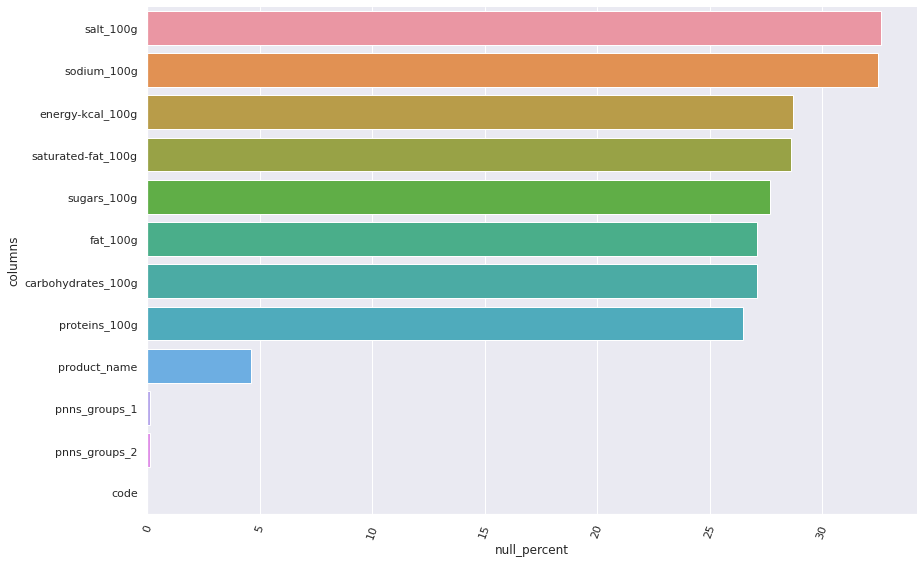

In [280]:
#to_remove check
show_nulls(sm_df)

In [283]:

sm_df.reset_index()

sm_df.to_csv(path + 'to_input_openfoodfacts.csv', index=False)
print('export finished !')

export finished !


## Imputing

In [179]:
#pip install -U scikit-learn

In [180]:
import numpy as np
from sklearn.impute import SimpleImputer


#all_num_cols = energy_cols + sm_num_cols

#imp_med = SimpleImputer(missing_values=np.nan, strategy='median')

###sm_df[all_num_cols] = imp_med.fit_transform(sm_df[all_num_cols])

In [181]:
# making sure to imput per category




In [182]:
sm_df.head()

,product_name,pnns_groups_1,pnns_groups_2,code,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
0,jeunes pousses,unknown,unknown,00000000000000225,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,L.casei,unknown,unknown,00000000000003429145,NaN,1.4,0.9,9.8,9.80,2.7,0.1,0.04
3,Cacao,unknown,unknown,0000000000031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Filetes de pollo empanado,unknown,unknown,000000000003327986,163.9,1.9,1.0,NaN,NaN,15.3,1.1,0.44
5,Burger Meat Pollo,unknown,unknown,000000000004128579,194.0,11.0,3.9,5.7,0.05,18.0,NaN,NaN


In [183]:
main_cats = sm_df['pnns_groups_1'].unique()
main_cats

array(['unknown', 'Fat and sauces', 'Composite foods', 'Sugary snacks',
       'Fruits and vegetables', 'Fish Meat Eggs', 'Beverages',
       'Milk and dairy products', 'Cereals and potatoes', 'Salty snacks',
       'Alcoholic beverages', nan, 'sugary-snacks'], dtype=object)

In [184]:
sm_df['pnns_groups_1'].value_counts()

unknown                    1166781
Fish Meat Eggs              114618
Milk and dairy products     100917
Cereals and potatoes         78293
Beverages                    70328
Fat and sauces               63673
Composite foods              58221
Fruits and vegetables        55942
Sugary snacks                47312
Salty snacks                 28204
Alcoholic beverages          20093
sugary-snacks                    2
Name: pnns_groups_1, dtype: int64

In [185]:
main_cats[0]

'unknown'

In [186]:
# dummy list of one element for loop  building purpose
#main_cats = ['Salty snacks']

In [187]:
#sm_df.loc[sm_df['pnns_groups_1'] == main_cats[0]]

In [188]:
#sm_df[all_num_cols] = imp_med.fit_transform(sm_df[all_num_cols])

In [189]:
#sm_df.loc[sm_df['pnns_groups_1'] == main_cats[0]]

In [190]:
#for i in main_cats:
#    single_cat_sm_df = sm_df.loc[sm_df['pnns_groups_1'] == main_cats[i]]
    #single_cat_sm_df[all_num_cols] = imp_med.fit_transform(single_cat_sm_df[all_num_cols])
    

In [191]:
sm_df['pnns_groups_1'].value_counts()

unknown                    1166781
Fish Meat Eggs              114618
Milk and dairy products     100917
Cereals and potatoes         78293
Beverages                    70328
Fat and sauces               63673
Composite foods              58221
Fruits and vegetables        55942
Sugary snacks                47312
Salty snacks                 28204
Alcoholic beverages          20093
sugary-snacks                    2
Name: pnns_groups_1, dtype: int64

In [192]:
all_cols = sm_df['pnns_groups_1'].unique().tolist()
all_cols

['unknown',
 'Fat and sauces',
 'Composite foods',
 'Sugary snacks',
 'Fruits and vegetables',
 'Fish Meat Eggs',
 'Beverages',
 'Milk and dairy products',
 'Cereals and potatoes',
 'Salty snacks',
 'Alcoholic beverages',
 nan,
 'sugary-snacks']

In [193]:
sm_df.columns

Index(['product_name', 'pnns_groups_1', 'pnns_groups_2', 'code',
       'energy-kcal_100g', 'fat_100g', 'saturated-fat_100g',
       'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'salt_100g',
       'sodium_100g'],
      dtype='object')

In [194]:
main_cats = ['fat_100g', 'salt_100g']
complementary_cats = ['saturated-fat_100g','sodium_100g']

In [195]:
final_cats = [c for c in all_cols if c not in main_cats+complementary_cats]
final_cats


['unknown',
 'Fat and sauces',
 'Composite foods',
 'Sugary snacks',
 'Fruits and vegetables',
 'Fish Meat Eggs',
 'Beverages',
 'Milk and dairy products',
 'Cereals and potatoes',
 'Salty snacks',
 'Alcoholic beverages',
 nan,
 'sugary-snacks']

In [196]:
### appliquer imputer différentes strategies (check distribution) avec un groupby categories
### iterative imputer / estimation du choix d'imputer selon la distribution (mean/median/most frequent...)


In [197]:
imp_med = SimpleImputer(missing_values=np.nan, strategy='median')
imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')

In [198]:
#groupby pnns_groups_1, mean, remplir avec mean / categorie
#list1 = ["fat_100g", "salt_100g"]
main_cats

['fat_100g', 'salt_100g']

In [199]:
sm_df[main_cats].head()

,fat_100g,salt_100g
0,NaN,NaN
1,1.4,0.1
3,NaN,NaN
4,1.9,1.1
5,11.0,NaN


In [200]:
main_cats_grp = main_cats.append('pnns_group_1')
main_cats_grp

In [201]:
print(main_cats_grp)

None


In [202]:
sm_df[main_cats_grp].head()

KeyError: None

In [101]:
sm_df[main_cats].groupby(by='pnns_groups_1')

KeyError: "['pnns_group_1'] not in index"

In [ ]:
sm_df[main_cats] = imp_med.fit_transform(sm_df[main_cats].groupby())

In [ ]:
# IterativeImputer avec estimator=LinearRegression()
#list2 = ["saturated-fat_100g", "sodium_100g"] 
complementary_cats

In [ ]:
sm_df[complementary_cats].head()

In [94]:
#Reste des variables contenant des valeurs vides (sans list1, list2,  pnns_groups_1, pnns_groups_2) : 
# remplir soit avec la moyenne soit avec la mediane, en fonction de la distribution 
#- remplir avec la valeur la plus fréquente



In [ ]:
sm_df.describe()

In [ ]:
sm_df.info(verbose=True)

In [ ]:
#to_remove check (mb not here ?)
show_nulls(sm_df)

In [ ]:
# simplimputer most frequent
pnns = ['pnns_groups_1', 'pnns_groups_2']

In [ ]:
imp_mf = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
sm_df[pnns] = imp_mf.fit_transform(sm_df[pnns])

In [ ]:
sm_df.describe()

In [ ]:
#to_remove check
show_nulls(sm_df)

In [ ]:
sm_df.shape

In [ ]:
df_prod_ct = sm_df['product_name'].value_counts(dropna=False).to_frame()
df_prod_ct_pct = sm_df['product_name'].value_counts(dropna=False, normalize=True).to_frame()

In [ ]:
df_prod_ct.head(20)

In [ ]:
df_prod_ct_pct.head(20)

### Product names

In [ ]:
#drop lines missing product names

In [ ]:
sm_df.dropna(axis=0, subset = ['product_name'], inplace = True)

In [ ]:
df_prod_ct = sm_df['product_name'].value_counts(dropna=False)
df_prod_ct_pct = sm_df['product_name'].value_counts(dropna=False, normalize=True)

In [ ]:
df_prod_ct.head(20)

In [ ]:
df_prod_ct_pct.head(20)

In [ ]:
sm_df.isna().sum().sum()

In [ ]:
sm_df.shape

### Barcodes

In [ ]:
# https://world.openfoodfacts.org/data/data-fields.txt
#code : barcode of the product (can be EAN-13 or internal codes for some food stores), 
#       for products without a barcode, Open Food Facts assigns a number starting with the 200 reserved prefix


In [ ]:
sm_df.shape

In [ ]:
# count code values
sm_df['code'].count()

In [ ]:
# count code values with 200 prefix
sm_df['code'].loc[sm_df['code'].str.startswith('200')].count()

In [ ]:
sm_df = sm_df.loc[~sm_df['code'].str.startswith('200')]

In [ ]:
sm_df.shape

In [ ]:
#to_remove check
show_nulls(sm_df)

# export to csv

In [ ]:
#sm_df.reset_index()

#sm_df.to_csv(path + 'clean_openfoodfacts_x.csv', index=False)
#print('export finished !')

In [ ]:
ls -lh ./data

In [ ]:
# univariée (histos) / bivariée (axes ++ / confusion matrix)

In [ ]:
#from sklearn.preprocessing import OneHotEncoder

#ohe = OneHotEncoder(sparse = False) #instanciate encoder
#ohe.fit(top_df[['pnns_groups_1']]) # fit encoder
#pnn1_encoded = ohe.transform(top_df[['pnns_groups_1']]) # encode pnn1
#